In [73]:
!git clone https://github.com/Nrrahat/Assingment_K_Mean.git

fatal: destination path 'Assingment_K_Mean' already exists and is not an empty directory.


In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import joblib

In [75]:
df = pd.read_csv(
    "Assingment_K_Mean/dataset/Mall_Customers.csv"
)

In [76]:
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [77]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [78]:
import os
import joblib

# 1. Define the path where you want to save the file
file_path = "model/scaler.pkl"

# 2. Extract the directory portion ("model")
directory = os.path.dirname(file_path)

# 3. Create the "model" folder if it doesn't exist yet
if directory and not os.path.exists(directory):
    os.makedirs(directory)
    print(f"Successfully created missing directory: {directory}")

# 4. Save your scaler
joblib.dump(scaler, file_path)
print("Success! scaler.pkl has been saved.")

Success! scaler.pkl has been saved.


In [79]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

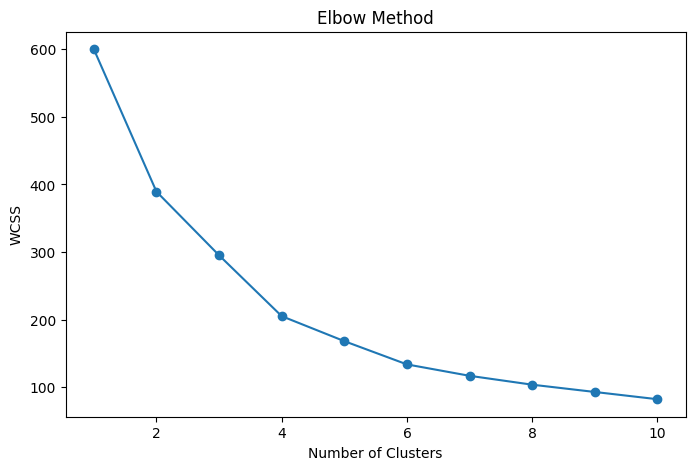

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [81]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [82]:
import os
import joblib

# 1. Define the path where you want to save the file
file_path = "model/kmeans.pkl"

# 2. Extract the directory portion ("model")
directory = os.path.dirname(file_path)

# 3. Create the "model" folder if it doesn't exist yet
if directory and not os.path.exists(directory):
    os.makedirs(directory)
    print(f"Successfully created missing directory: {directory}")

# 4. Save your scaler
joblib.dump(scaler, file_path)
print("Success! kmeans.pkl has been saved.")

Success! kmeans.pkl has been saved.


In [83]:
df["Cluster"] = kmeans.labels_

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


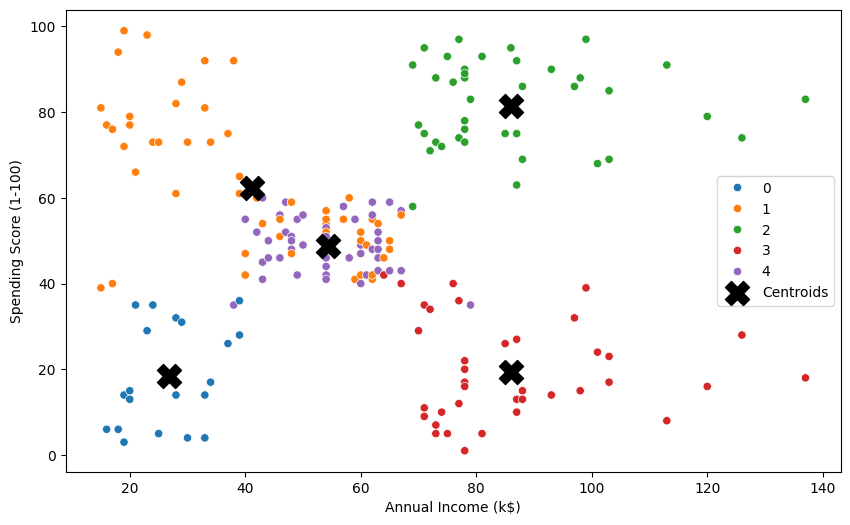

In [84]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10"
)

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

plt.scatter(
    centers[:,1],
    centers[:,2],
    s=300,
    marker="X",
    color="black",
    label="Centroids"
)

plt.legend()
plt.show()

In [85]:
import os

print("--- Current Location ---")
print(os.getcwd())

print("\n--- Files & Folders Visible Here ---")
print(os.listdir())
import os
print(os.listdir("dataset"))

--- Current Location ---
/content/Assingment_K_Mean

--- Files & Folders Visible Here ---
['Assingment_K_Mean', 'dataset', 'model', '.git', 'README.md']
['Mall_Customers.csv']


In [86]:
custom_df = pd.read_csv("Assingment_K_Mean/dataset/custom_customers.csv")

In [87]:
custom_df


,Age,Annual Income (k$),Spending Score (1-100)
0,21,25,80
1,24,30,76
2,29,45,65
3,35,60,55
4,40,65,50
5,45,70,40
6,50,80,35
7,55,85,30
8,32,50,60
9,27,40,70


In [88]:
import joblib

# Load using the path relative to your current location
saved_scaler = joblib.load("model/scaler.pkl")

# Now apply it to your dataset
custom_scaled = saved_scaler.transform(custom_df)
print("Scaler loaded and data transformed successfully!")

Scaler loaded and data transformed successfully!


In [89]:
custom_df["Assigned Cluster"] = kmeans.predict(custom_scaled)

columns_to_print = ["Age", "Annual Income (k$)", "Spending Score (1-100)", "Assigned Cluster"]
print(custom_df[columns_to_print])

   Age  Annual Income (k$)  Spending Score (1-100)  Assigned Cluster
0   21                  25                      80                 1
1   24                  30                      76                 1
2   29                  45                      65                 1
3   35                  60                      55                 1
4   40                  65                      50                 4
5   45                  70                      40                 4
6   50                  80                      35                 3
7   55                  85                      30                 3
8   32                  50                      60                 1
9   27                  40                      70                 1


In [90]:
print(
    custom_df[
        [
            "Age",
            "Annual Income (k$)",
            "Spending Score (1-100)",
            "Assigned Cluster"
        ]
    ]
)

   Age  Annual Income (k$)  Spending Score (1-100)  Assigned Cluster
0   21                  25                      80                 1
1   24                  30                      76                 1
2   29                  45                      65                 1
3   35                  60                      55                 1
4   40                  65                      50                 4
5   45                  70                      40                 4
6   50                  80                      35                 3
7   55                  85                      30                 3
8   32                  50                      60                 1
9   27                  40                      70                 1
